# AT-TPC Latent Space Exploration
---
This notebook explores AT-TPC event embeddings with k-means, PCA projection, PCA variance analysis, UMAP, t-SNE.

In [1]:
import os
import sys
import numpy as np
sys.path.append('../../')
from clustering import t_SNE_clustering
from clustering import UMAP_embedding
from clustering import k_means_clustering
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
# create a folder for results of global feature exploration

folder_path = 'home/DAVIDSON/tomallenntiador/torchSparseContrastive/plots/exploration'
if not os.path.exists(folder_path):
  os.makedirs(folder_path, exist_ok=True)

## 1. Load Data
---
Set the feature and label paths, then load the `.npy` files.

By default, labels are used exactly as they appear in the file. Plot legends use the label values from the file, such as `0`, `1`, `2` or text values like `cat` and `dog`, unless you provide custom names.

**`label_groups`** (optional): combine raw label values into fewer classes. Set to `None` to skip regrouping. Each inner list becomes one class. Works with numeric or text labels.

**`class_names`** (optional): custom legend names. Leave as `None` to use the label values from the file. If provided, include one name per unique label after any regrouping.



In [3]:
# Set file paths
features_path = '../../embeddings/O16_simclr_best/latent_vectors.npy' # CHANGE THE NAME OF THE DATA FILE AS NEEDED
labels_path = '../../embeddings/O16_simclr_best/labels.npy' # CHANGE THE NAME OF THE DATA FILE AS NEEDED

# Optional: regroup raw label values into fewer classes.
# None = use labels from the file as-is (default).
label_groups = None
# Numeric example:
# label_groups = [
#     [0, 1, 2],
#     [3],
#     [4, 5],
# ]
# Text example:
# label_groups = [
#     ["cat"],
#     ["dog"],
# ]

# Optional display names for plot legends.
# None = use label values from the file, such as "0", "1", "2" or "cat", "dog".
class_names = None
# class_names = ["Class 0", "Class 1", "Class 2"]

features = np.load(features_path)
print(f"Features loaded successfully! Shape: {features.shape}")

Features loaded successfully! Shape: (2458, 128)


In [4]:
# Load labels
label_data = np.load(labels_path)

In [5]:
def load_labels(label_data):
    labels = np.asarray(label_data).ravel()
    if np.issubdtype(labels.dtype, np.number):
        return labels.astype(int)
    return labels.astype(str)

def apply_label_groups(labels, groups):
    if groups is None:
        return labels
    mapped = labels.copy()
    for new_label, raw_values in enumerate(groups):
        mapped[np.isin(labels, raw_values)] = new_label
    return mapped

labels = load_labels(label_data)
labels = apply_label_groups(labels, label_groups)

if class_names is not None and len(class_names) != len(np.unique(labels)):
    raise ValueError(
        f"class_names must have {len(np.unique(labels))} entries, got {len(class_names)}"
    )

print("Unique labels:", np.unique(labels))
print("Label counts:", {str(v): int(np.sum(labels == v)) for v in np.unique(labels)})

features = StandardScaler().fit_transform(features)
print(f"Data scaled successfully! {features.shape}")

Unique labels: [0 1 2]
Label counts: {'0': 1184, '1': 476, '2': 798}
Data scaled successfully! (2458, 128)


## 2. K-Means
---
Run k-means on the embeddings, seperating them into k clusters. The clusters can then be compared with the grouped labels, using `class_names` for legend text when it is provided.

In [6]:
save_dir = './plots/k_means'

features_glob, cluster_labels, cluster_indices = k_means_clustering(
    features,
    labels,
    dimension=2,
    save_dir=save_dir,
    num_samples_to_print=10,
    class_names=class_names
)


Random sample indices from each cluster:
Cluster 0: [1987, 362, 50, 400, 2379, 2266, 625, 1387, 1651, 448]
Cluster 1: [560, 841, 1643, 2311, 395, 1385, 1030, 643, 522, 193]
Cluster 2: [1515, 509, 1805, 1709, 1562, 44, 2362, 1985, 1488, 2417]


## 3. PCA Projection
---
Use PCA as a baseline before UMAP and t-SNE. PCA can project the scaled embeddings into either 2D or 3D by changing `dimension`. It shows the main directions of variation and uses the same labels and optional `class_names` as the other plots.

In [7]:
from clustering import pca_clustering

save_dir = './plots/pca'

# Use dimension=2 for a 2D plot or dimension=3 for a 3D plot.
pca_results = pca_clustering(
    features,
    labels,
    dimension=2,
    save_dir=save_dir,
    class_names=class_names
)

## 3b. PCA Variance Analysis
---
Fit PCA on all embedding dimensions and report how many principal components are needed to reach a target explained-variance threshold (default 95%). The cumulative variance plot is saved under `./plots/pca/variance/`.

In [8]:
from clustering import pca_variance_analysis

variance_threshold = 0.95

variance_results = pca_variance_analysis(
    features,
    variance_threshold=variance_threshold,
    save_dir="./plots/pca",
    plot_name="exploration",
)

variance_results["n_components"]


PCA variance analysis: 34 component(s) explain 95.3% of variance (threshold=95%)


34

## 4. Check Cluster Labels
---
Print the true labels for the sampled events in each cluster.

In [9]:
def true_labels(indices, labels):
    c_labels = []
    for index in indices:
        c_labels.append(labels[index])

    return c_labels

print("True labels verification per cluster:")
for i, cluster in enumerate(cluster_indices):
    print(f"Cluster {i}: {true_labels(cluster, labels)}")

True labels verification per cluster:
Cluster 0: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Cluster 1: [np.int64(2), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(0)]
Cluster 2: [np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(0), np.int64(2), np.int64(2), np.int64(1), np.int64(2), np.int64(2)]


## 5. UMAP Visualization
---
Run UMAP on the embeddings and color the 2D plot by label. The main hyperparameter to change is `neighbors`, which controls how much local structure UMAP preserves. The plot uses label values from the file unless `class_names` is set, saves under `./plots/umap/`, and stores the coordinates in `umap_results`.

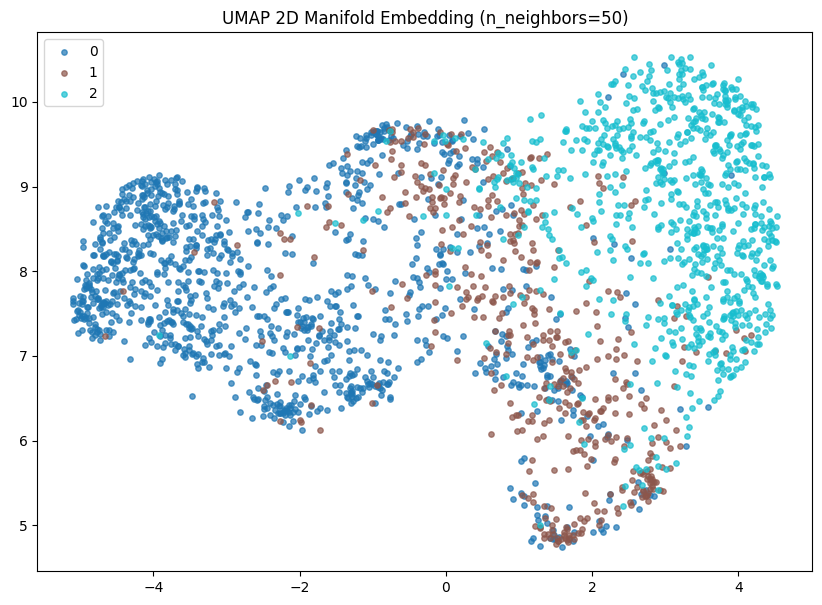

In [10]:
neighbors = 50
fig, ax = plt.subplots(figsize=(10, 7))

umap_results = UMAP_embedding(
    features,
    dimension=2,
    ax=ax,
    labels=labels,
    neighbors=neighbors,
    class_names=class_names,
    save_dir='./plots'
)

ax.legend()
plt.title(f"UMAP 2D Manifold Embedding (n_neighbors={neighbors})")
plt.savefig('./plots/umap/umap_unified_manifold.png', dpi=200)
plt.show()

## 6. t-SNE Visualization
---
Run t-SNE on the embeddings and color the 2D plot by label. The main hyperparameter to change is `perplexity`, which controls how many nearby points t-SNE considers when building the embedding. The plot uses label values from the file unless `class_names` is set. t-SNE is useful for local structure, but far-apart distances should be interpreted carefully. The plot is saved under `./plots/t-sne/`, and the coordinates are stored in `tsne_results`.

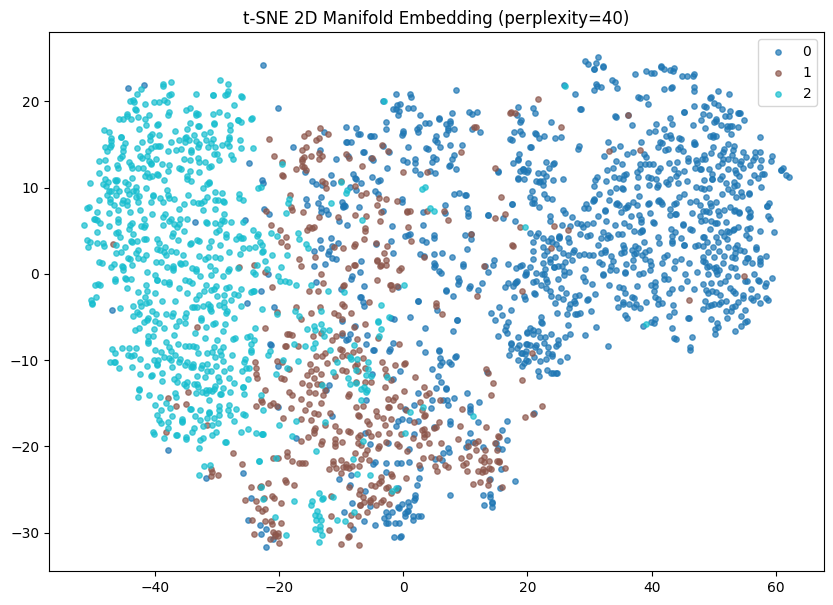

In [11]:
perplexity = 40
fig, ax = plt.subplots(figsize=(10, 7))

tsne_results = t_SNE_clustering(
    features,
    dimension=2,
    ax=ax,
    labels=labels,
    perplexity=perplexity,
    class_names=class_names,
    save_dir='./plots'
)

ax.legend()
plt.title(f"t-SNE 2D Manifold Embedding (perplexity={perplexity})")
plt.savefig('./plots/t-sne/tsne_unified_manifold.png', dpi=200)
plt.show()